# SIR model of an emerging infection
## Basic model
### Model construction
In this notebook, we will use the `summer` interface 
to demonstrate the construction of a simple model that loosely
captures some of the features of an outbreak of a novel infection.

The model consists of:
- Three compartments, named `susceptible`, `infectious` and `recovered`
- A starting population of seven million people, with one of them infectious
- An evaluation timespan from time zero to 100 days
- Inter-compartmental flows for the infection and recovery processes

Susceptible, infectious, recovered is a very commonly used model structure,
although many variations on this exist,
some of which will be explored in later notebooks.

The next cell installs our `summer` package imports some standard libraries
You don't need to worry about what these are at all,
unless you happen to have a background in data science,
in which case several may be familiar.

In [ ]:
# Install summer
%pip install summerepi2==1.3.6

# Pandas for data wrangling and use plotly module for interactive visualisation
import pandas as pd
pd.options.plotting.backend = "plotly"

# Various components of our "summer" platform for building models of epidemics
from summer2 import CompartmentalModel
from summer2.parameters import Parameter, DerivedOutput
from summer2.functions.time import get_linear_interpolation_function as linear_interp

### Building the model with summer
First, let's create a function that gives us a basic SIR model with its
standard compartments, starting populations and inter-compartmental flows implemented.
![](../images/sir_structure.svg)

Our `summer` library can be used to construct a model with any structure you like,
but we suggest you leave this code unchanged if you're more interested in the epidemiology.
The code is intended to be epidemiologically expressive, so don't assume you won't understand it,
but we appreciate not everyone like code!
You can easily adjust things like the starting population, the size of the infectious seed and the time period
that the simulation will run over at the start of the cell.

In [ ]:
total_population = 7e6  # 7 million people to loosely represent Victoria
infectious_seed = 1.0  # One infectious person to introduce into the model
run_period = [0.0, 40.0]  # Run from time zero to time 40
model_comps = ["susceptible", "infectious", "recovered"]  # Compartments
infect_comps = ["infectious"]  # Only the "infectious" compartment will be infectious
sir_model = CompartmentalModel(times=run_period, compartments=model_comps, infectious_compartments=infect_comps, timestep=0.2)  # Build the model
start_pop = {"susceptible": total_population - infectious_seed, "infectious": infectious_seed}  # Assign everyone susceptible except the seed
sir_model.set_initial_population(start_pop)
sir_model.add_infection_frequency_flow(name="infection", contact_rate=Parameter("contact_rate"), source="susceptible", dest="infectious")
sir_model.add_transition_flow(name="recovery", fractional_rate=Parameter("recovery_rate"), source="infectious", dest="recovered")

### Running the model
Now we have a model set up that we're ready to run.
The model is expecting us to give it some parameters,
because this is what we promised when we said that the
rate of infection and recovery were set with a `Parameter` object.
Run this cell and then feel free to adjust the parameters to see
how the behaviour of the model changes.

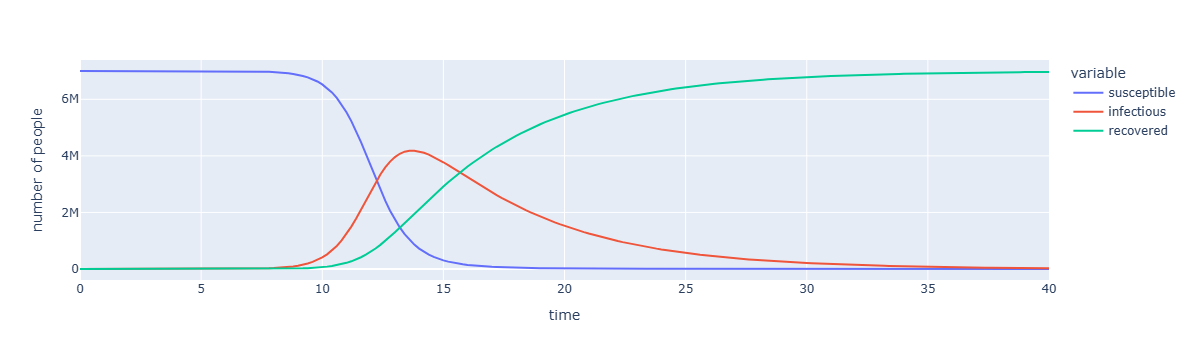

In [3]:
parameters = {
    "contact_rate": 1.5,
    "recovery_rate": 0.2,
}
sir_model.run(parameters)
sir_model.get_outputs_df().plot(labels={"index": "time", "value": "number of people"})

### Interpretation
These parameters may not be very intuitive,
because they are rates per unit time.
So for example, a recovery rate of 0.2 per day
implies that if you have a group of infectious people
then approximately 20% of them will recover each day.
We can also say that the average time infectious is five days.

The contact rate in this model is the number of people who 
will be infected by an infectious person each day of their infection.
Because we have already calculated that they will be infectious
for five days, we can calculate the basic reproduction number $R_{0}$
to be 7.5.

That is these simple calculations are:

In [4]:
infectious_duration = 1.0 / parameters["recovery_rate"]
print(f"The infectious duration is {infectious_duration} days")
basic_reproduction_number = parameters["contact_rate"] * infectious_duration
print(f"The basic reproduction number is {basic_reproduction_number}")

The infectious duration is 5.0 days
The basic reproduction number is 7.5


### Limitations
This is a really simple model that doesn't capture many features of
a real infectious disease outbreak.
In particular, there is no random element to it (i.e. it is deterministic)
and the number of people transitioning between the compartments
is calculated by applying the transition rates directly to the calculated compartment sizes.
This means that the calcuated compartment sizes will not be whole numbers.

Nevertheless, it does capture many of the features that we might expect
from a real epidemic of a new infectious disease spreading through
a susceptible population.
Can you list some of these?

### What can we do with a model like this?
So what's the purpose of this model?
Clearly it has several limitations, 
but does also capture quite a few aspects of a real-world epidemic,
including its general shape.
Also, we have now built a "mechanistic" simulation;
that is, we have captured the underlying mechanism of transmission.
This allows us to understand what's happening under the surface
and look at changes to the system that might result from 
public health interventions.